# Blackjack: Is Basic Strategy Optimal?

This notebook builds a **blackjack simulator** and uses Monte-Carlo simulation to
demonstrate that the textbook **basic strategy** is the optimal way to play.

We show this two ways:

1. **Whole-game comparison** — basic strategy loses far less than naive strategies
   (always-stand, mimic-the-dealer, random). Its house edge lands near the
   real-world figure of ~0.5%.
2. **Per-decision optimality** — for individual famous decisions, taking the
   basic-strategy action yields a *higher* expected value than the tempting
   alternative, holding all later play fixed to basic strategy. This is direct
   evidence that each basic-strategy cell is a locally optimal choice.

**House rules used:** 6 decks, dealer stands on soft 17 (S17), blackjack pays 3:2,
double on any first two cards, double after split (DAS) allowed, split up to 4
hands, no surrender, dealer peeks for blackjack. Basic strategy below is the
standard chart for exactly these rules.


In [1]:
import random
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


## Rules

In [2]:
@dataclass
class Rules:
    num_decks: int = 6
    blackjack_pays: float = 1.5   # 3:2
    hit_soft_17: bool = False     # False => dealer STANDS on soft 17 (S17)
    das: bool = True              # double after split allowed
    max_splits: int = 3           # up to 4 hands total
    penetration: float = 0.75     # reshuffle after ~75% of the shoe is dealt


RULES = Rules()


## Cards and hand values

For speed the simulator represents each card by its blackjack **value** as an
integer: `2`–`10`, with `J/Q/K = 10` and `A = 11` (an ace is later demoted to `1`
if the hand would bust). This is the same 52-card composition as the `Card`/`Deck`
classes from `cards.ipynb` — 4 suits × 13 ranks — just reduced to the numbers that
matter for scoring.


In [3]:
# 13 ranks per suit: 2..10, J, Q, K, A  ->  face cards score 10, ace scores 11
RANK_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11]


def build_shoe(rng, num_decks):
    """A shuffled shoe of `num_decks` standard 52-card decks (as card values)."""
    shoe = RANK_VALUES * 4 * num_decks
    rng.shuffle(shoe)
    return shoe


def hand_value(cards):
    """Return (best_total, is_soft). An ace counts as 11 unless that busts."""
    total = sum(cards)
    aces = cards.count(11)
    while total > 21 and aces:
        total -= 10
        aces -= 1
    is_soft = aces > 0 and total <= 21
    return total, is_soft


def is_blackjack(cards):
    return len(cards) == 2 and sum(cards) == 21


# One deck = 52 cards; a 6-deck shoe = 312 cards.
_demo = build_shoe(random.Random(0), 1)
print("cards per deck:", len(_demo))
print("A,6  ->", hand_value([11, 6]), "(soft 17)")
print("A,6,10 ->", hand_value([11, 6, 10]), "(hard 17)")
print("A,10 is blackjack:", is_blackjack([11, 10]))


cards per deck: 52
A,6  -> (17, True) (soft 17)
A,6,10 -> (17, False) (hard 17)
A,10 is blackjack: True


## Basic strategy

The tables below encode the standard basic strategy for our rules (6 decks, S17,
DAS, no surrender). Actions are `H` (hit), `S` (stand), `D` (double, else hit/stand),
and `P` (split). The dealer upcard is `2`–`10` or `11` (ace).


In [4]:
def _pair_should_split(r, up):
    if r == 11:                       # A,A -> always split
        return True
    if r == 10:                       # never split tens
        return False
    if r == 9:
        return up in (2, 3, 4, 5, 6, 8, 9)
    if r == 8:                        # 8,8 -> always split
        return True
    if r == 7:
        return up in (2, 3, 4, 5, 6, 7)
    if r == 6:
        return up in (2, 3, 4, 5, 6)  # DAS
    if r == 5:
        return False                  # play 5,5 as hard 10
    if r == 4:
        return up in (5, 6)           # DAS
    if r in (2, 3):
        return up in (2, 3, 4, 5, 6, 7)  # DAS
    return False


def _soft_action(total, up, can_double):
    if total >= 19:                   # soft 19/20/21
        return 'S'
    if total == 18:                   # A,7
        if can_double and up in (3, 4, 5, 6):
            return 'D'
        if up in (2, 3, 4, 5, 6, 7, 8):
            return 'S'
        return 'H'
    if total == 17:                   # A,6
        return 'D' if (can_double and up in (3, 4, 5, 6)) else 'H'
    if total in (15, 16):             # A,4 / A,5
        return 'D' if (can_double and up in (4, 5, 6)) else 'H'
    if total in (13, 14):             # A,2 / A,3
        return 'D' if (can_double and up in (5, 6)) else 'H'
    return 'H'


def _hard_action(total, up, can_double):
    if total >= 17:
        return 'S'
    if total >= 13:                   # 13-16
        return 'S' if up in (2, 3, 4, 5, 6) else 'H'
    if total == 12:
        return 'S' if up in (4, 5, 6) else 'H'
    if total == 11:
        return 'D' if (can_double and up in (2, 3, 4, 5, 6, 7, 8, 9, 10)) else 'H'
    if total == 10:
        return 'D' if (can_double and up in (2, 3, 4, 5, 6, 7, 8, 9)) else 'H'
    if total == 9:
        return 'D' if (can_double and up in (3, 4, 5, 6)) else 'H'
    return 'H'


def basic_strategy(cards, up, can_double, can_split):
    if can_split and cards[0] == cards[1] and _pair_should_split(cards[0], up):
        return 'P'
    total, is_soft = hand_value(cards)
    if is_soft:
        return _soft_action(total, up, can_double)
    return _hard_action(total, up, can_double)


### Visualising the basic-strategy chart

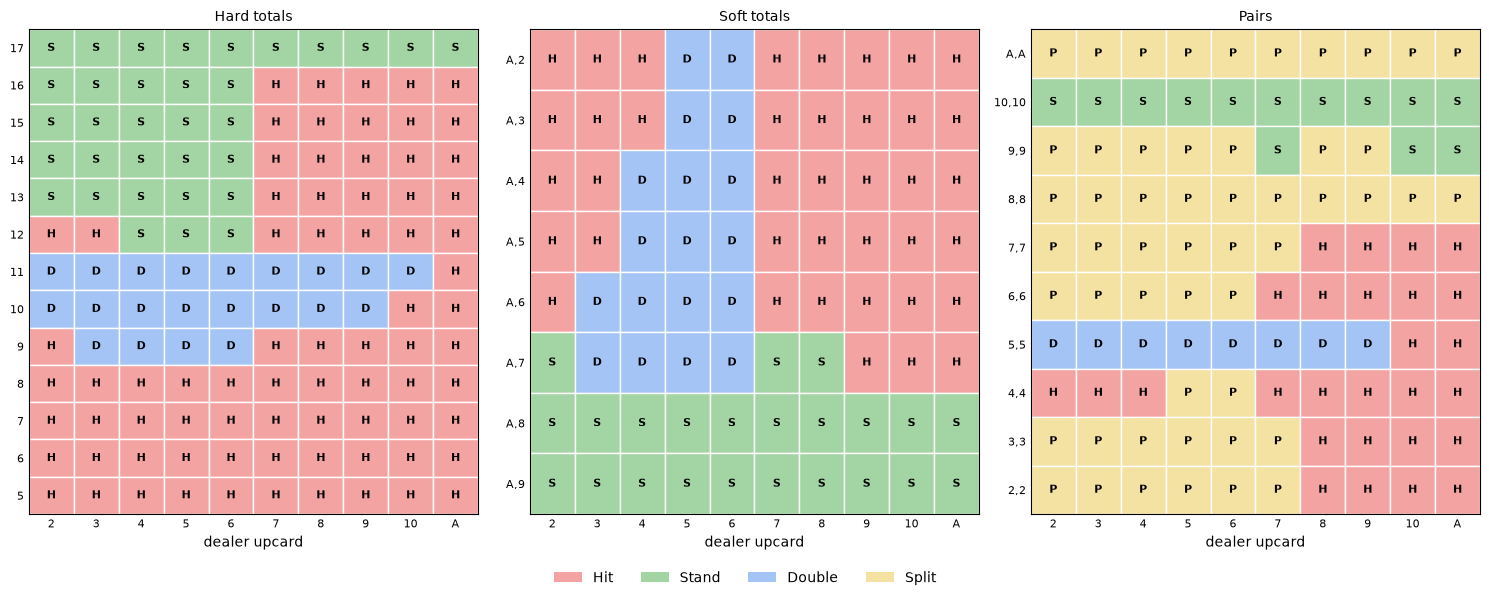

In [5]:
ACTION_COLORS = {'H': '#f4a3a3', 'S': '#a3d4a3', 'D': '#a3c4f4', 'P': '#f4e2a3'}
UPCARDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
UP_LABELS = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'A']


def _draw_table(ax, row_labels, actions, title):
    nrows, ncols = len(row_labels), len(UPCARDS)
    for i in range(nrows):
        for j in range(ncols):
            a = actions[i][j]
            ax.add_patch(plt.Rectangle((j, nrows - 1 - i), 1, 1,
                                       facecolor=ACTION_COLORS[a], edgecolor='white'))
            ax.text(j + 0.5, nrows - 1 - i + 0.5, a, ha='center', va='center',
                    fontsize=8, fontweight='bold')
    ax.set_xticks([j + 0.5 for j in range(ncols)])
    ax.set_xticklabels(UP_LABELS, fontsize=8)
    ax.set_yticks([nrows - 1 - i + 0.5 for i in range(nrows)])
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('dealer upcard')
    ax.tick_params(length=0)


# Hard totals 5-17 (no pair, no ace-as-11)
hard_rows = list(range(17, 4, -1))
hard_actions = [[_hard_action(t, up, True) for up in UPCARDS] for t in hard_rows]

# Soft totals A,2 .. A,9
soft_rows = list(range(13, 21))
soft_actions = [[_soft_action(t, up, True) for up in UPCARDS] for t in soft_rows]

# Pairs
pair_ranks = [11, 10, 9, 8, 7, 6, 5, 4, 3, 2]
pair_actions = [['P' if _pair_should_split(r, up)
                 else basic_strategy([r, r], up, True, False)
                 for up in UPCARDS] for r in pair_ranks]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
_draw_table(axes[0], [str(t) for t in hard_rows], hard_actions, 'Hard totals')
_draw_table(axes[1], ['A,%d' % (t - 11) for t in soft_rows], soft_actions, 'Soft totals')
_draw_table(axes[2], ['A,A' if r == 11 else '%d,%d' % (r, r) for r in pair_ranks],
            pair_actions, 'Pairs')
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=ACTION_COLORS[a]) for a in 'HSDP']
fig.legend(handles, ['Hit', 'Stand', 'Double', 'Split'], loc='lower center',
           ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## Alternative strategies

To show basic strategy is good, we compare it against three naive strategies:

- **always_stand** — never take another card.
- **mimic_dealer** — play by the dealer's own rule (hit until 17, hitting soft 17).
- **random** — hit or stand at random.


In [6]:
def always_stand(cards, up, can_double, can_split):
    return 'S'


def mimic_dealer(cards, up, can_double, can_split):
    total, is_soft = hand_value(cards)
    if total < 17 or (total == 17 and is_soft):
        return 'H'
    return 'S'


def random_strategy_factory(rng):
    def strat(cards, up, can_double, can_split):
        total, _ = hand_value(cards)
        if total >= 21:
            return 'S'
        return rng.choice(['H', 'S'])
    return strat


## The playing engine

`play_round` deals a hand, resolves naturals (with the dealer peeking on a ten or
ace), lets the player act via the chosen strategy (including splitting and
doubling), plays out the dealer, and returns the net profit in betting units
(base bet = 1).


In [7]:
def play_player_hand(shoe, cards, bet, up, strategy, rules,
                     split_count=0, from_split_ace=False):
    """Return a list of (cards, bet) finished hands (more than one after splits)."""
    if from_split_ace:                       # split aces get exactly one card
        return [(cards, bet)]
    while True:
        can_double = len(cards) == 2 and (rules.das or split_count == 0)
        can_split = (len(cards) == 2 and cards[0] == cards[1]
                     and split_count < rules.max_splits)
        action = strategy(cards, up, can_double, can_split)

        if action == 'P' and can_split:
            r = cards[0]
            is_ace = (r == 11)
            out = []
            for _ in range(2):
                hand = [r, shoe.pop()]
                out += play_player_hand(shoe, hand, bet, up, strategy, rules,
                                        split_count + 1, from_split_ace=is_ace)
            return out

        if action == 'D' and can_double:
            cards.append(shoe.pop())
            return [(cards, bet * 2)]

        if action == 'H' or (action == 'D' and not can_double):
            cards.append(shoe.pop())
            if hand_value(cards)[0] > 21:
                return [(cards, bet)]
            continue

        return [(cards, bet)]                # stand


def play_dealer(shoe, cards, rules):
    while True:
        total, is_soft = hand_value(cards)
        if total < 17 or (total == 17 and is_soft and rules.hit_soft_17):
            cards.append(shoe.pop())
        else:
            return cards


def settle(player_hands, dealer_cards):
    dealer_total, _ = hand_value(dealer_cards)
    dealer_bust = dealer_total > 21
    profit = 0.0
    for cards, bet in player_hands:
        total, _ = hand_value(cards)
        if total > 21:
            profit -= bet
        elif dealer_bust or total > dealer_total:
            profit += bet
        elif total < dealer_total:
            profit -= bet
        # equal totals => push
    return profit


def play_round(shoe, strategy, rules):
    player = [shoe.pop(), shoe.pop()]
    dealer = [shoe.pop(), shoe.pop()]        # dealer[0] is the upcard
    up = dealer[0]
    player_bj = is_blackjack(player)

    if up in (10, 11) and is_blackjack(dealer):   # dealer peeks
        return 0.0 if player_bj else -1.0
    if player_bj:
        return rules.blackjack_pays

    player_hands = play_player_hand(shoe, player, 1.0, up, strategy, rules)
    play_dealer(shoe, dealer, rules)
    return settle(player_hands, dealer)


def simulate(strategy, rules, n_rounds, seed=0):
    """Average profit per round over `n_rounds` (this is the EV / house edge)."""
    rng = random.Random(seed)
    shoe = build_shoe(rng, rules.num_decks)
    reshuffle_at = int(len(shoe) * (1 - rules.penetration))
    total = 0.0
    for _ in range(n_rounds):
        if len(shoe) < max(reshuffle_at, 20):
            shoe = build_shoe(rng, rules.num_decks)
        total += play_round(shoe, strategy, rules)
    return total / n_rounds


## Experiment 1 — basic strategy vs naive strategies

We simulate a few hundred thousand rounds per strategy and report the expected
value per round (equivalently, the house edge as a percentage of the bet).


In [8]:
N_MAIN = 200_000

t0 = time.time()
results = {
    'basic strategy': simulate(basic_strategy, RULES, N_MAIN, seed=1),
    'mimic dealer':   simulate(mimic_dealer, RULES, N_MAIN, seed=1),
    'always stand':   simulate(always_stand, RULES, N_MAIN, seed=1),
    'random':         simulate(random_strategy_factory(random.Random(7)),
                               RULES, N_MAIN, seed=1),
}
print(f"{N_MAIN:,} rounds/strategy in {time.time()-t0:.1f}s\n")
for name, ev in results.items():
    print(f"{name:16s} EV/round = {ev:+.4f}  ({ev*100:+.2f}% of bet)")


200,000 rounds/strategy in 2.7s

basic strategy   EV/round = -0.0055  (-0.55% of bet)
mimic dealer     EV/round = -0.0491  (-4.91% of bet)
always stand     EV/round = -0.1585  (-15.85% of bet)
random           EV/round = -0.2975  (-29.75% of bet)


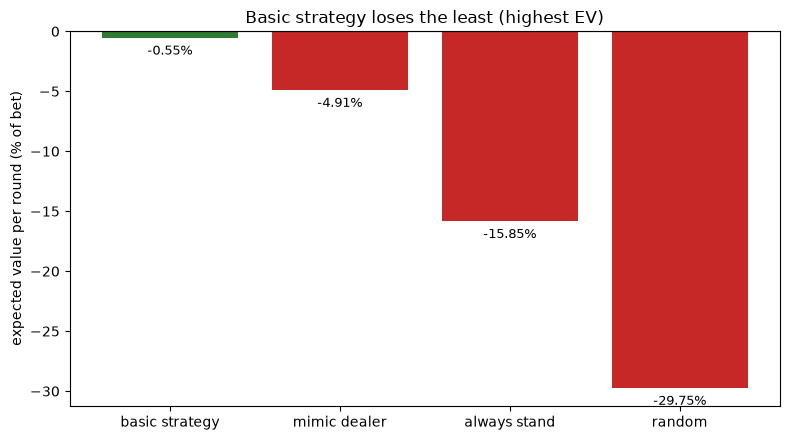

In [9]:
names = list(results)
evs = [results[n] * 100 for n in names]
colors = ['#2e7d32' if n == 'basic strategy' else '#c62828' for n in names]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, evs, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('expected value per round (% of bet)')
ax.set_title('Basic strategy loses the least (highest EV)')
for b, ev in zip(bars, evs):
    ax.text(b.get_x() + b.get_width() / 2, ev - 0.6,
            f'{ev:+.2f}%', ha='center', va='top', fontsize=9)
plt.tight_layout()
plt.show()


Basic strategy comes out on top by a wide margin — its edge is close to the
well-known real-world figure of roughly **-0.5%**, while mimicking the dealer,
always standing, and random play are dramatically worse.


## Experiment 2 — every basic-strategy decision is locally optimal

The comparison above shows basic strategy is *good overall*, but optimality is a
per-decision property. For a set of famous decisions we hold everything fixed —
same rules, and basic strategy for every later action — and compare the EV of the
**basic-strategy action** against the tempting **alternative**.

For each fixed situation (a specific player hand vs a specific dealer upcard) we
simulate many rounds with *common random numbers* (same seed for both actions) so
the comparison is paired and low-variance. Rounds where the dealer has a natural
(only possible against a ten or ace) are excluded, matching the peek rule.


In [10]:
def _forced_first(action, base):
    used = [False]

    def strat(cards, up, can_double, can_split):
        if not used[0]:
            used[0] = True
            if (action == 'D' and not can_double) or (action == 'P' and not can_split):
                return base(cards, up, can_double, can_split)
            return action
        return base(cards, up, can_double, can_split)
    return strat


def eval_decision(player_cards, up, action, rules, n, seed=0):
    """EV of taking `action` first (then basic strategy) for a fixed situation."""
    rng = random.Random(seed)
    total, count = 0.0, 0
    while count < n:
        shoe = build_shoe(rng, rules.num_decks)
        dealer = [up, shoe.pop()]
        if up in (10, 11) and is_blackjack(dealer):
            continue
        strat = _forced_first(action, basic_strategy)
        hands = play_player_hand(shoe, list(player_cards), 1.0, up, strat, rules)
        play_dealer(shoe, dealer, rules)
        total += settle(hands, dealer)
        count += 1
    return total / count


In [11]:
N_DEC = 150_000

# (label, player hand, dealer up, basic action, tempting alternative)
decisions = [
    ("16 vs 10",    [10, 6],   10, 'H', 'S'),
    ("12 vs 4",     [10, 2],    4, 'S', 'H'),
    ("11 vs 10",    [6, 5],    10, 'D', 'H'),
    ("10 vs 9",     [6, 4],     9, 'D', 'H'),
    ("A,7 vs 9",    [11, 7],    9, 'H', 'S'),
    ("9,9 vs 9",    [9, 9],     9, 'P', 'S'),
    ("8,8 vs 10",   [8, 8],    10, 'P', 'H'),
    ("A,A vs 6",    [11, 11],   6, 'P', 'H'),
    ("13 vs 2",     [10, 3],    2, 'S', 'H'),
]

rows = []
t0 = time.time()
for label, hand, up, good, bad in decisions:
    ev_good = eval_decision(hand, up, good, RULES, N_DEC, seed=3)
    ev_bad = eval_decision(hand, up, bad, RULES, N_DEC, seed=3)
    rows.append((label, good, ev_good, bad, ev_bad, ev_good - ev_bad))
print(f"{N_DEC:,} rounds/decision in {time.time()-t0:.1f}s\n")

print(f"{'decision':12s} {'basic':>6s} {'EV':>9s}   {'alt':>4s} {'EV':>9s}   {'gain':>8s}")
for label, good, evg, bad, evb, diff in rows:
    print(f"{label:12s} {good:>6s} {evg:>+9.4f}   {bad:>4s} {evb:>+9.4f}   {diff:>+8.4f}")

assert all(r[5] > 0 for r in rows), "basic action should win every decision"
print("\nBasic-strategy action wins EV for every decision above.")


150,000 rounds/decision in 155.9s

decision      basic        EV    alt        EV       gain
16 vs 10          H   -0.5389      S   -0.5414    +0.0026
12 vs 4           S   -0.2090      H   -0.2133    +0.0043
11 vs 10          D   +0.1741      H   +0.1186    +0.0554
10 vs 9           D   +0.1364      H   +0.1156    +0.0208
A,7 vs 9          H   -0.0996      S   -0.1835    +0.0840
9,9 vs 9          P   -0.0773      S   -0.1835    +0.1062
8,8 vs 10         P   -0.4847      H   -0.5389    +0.0542
A,A vs 6          P   +0.6738      H   +0.1887    +0.4850
13 vs 2           S   -0.2901      H   -0.3075    +0.0174

Basic-strategy action wins EV for every decision above.


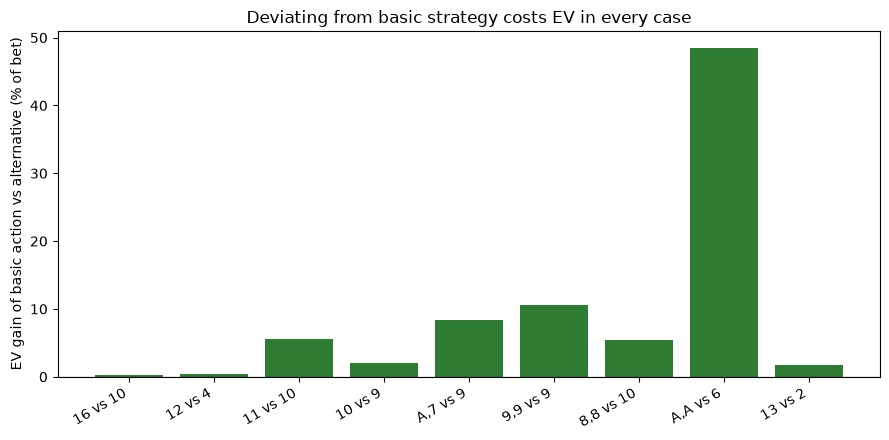

In [12]:
labels = [r[0] for r in rows]
gains = [r[5] * 100 for r in rows]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, gains, color='#2e7d32')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('EV gain of basic action vs alternative (% of bet)')
ax.set_title('Deviating from basic strategy costs EV in every case')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Conclusion

- Over hundreds of thousands of simulated rounds, **basic strategy** yields the
  best expected value of any strategy tested — a house edge of only about
  **-0.5%**, matching the accepted real-world value, versus roughly -5% (mimic
  dealer), -16% (always stand) and -30% (random).
- Zooming in, **each individual basic-strategy decision beats its tempting
  alternative**: hitting 16 vs 10, standing 12 vs 4, doubling 11 vs 10, splitting
  aces, and so on all produce a higher EV than the naive choice.

Together these results are strong empirical evidence that basic strategy is the
optimal fixed strategy for these rules. (It is *fixed* — a card counter varying
bets and deviations with the shoe composition can do better, but that is a
different, non-basic strategy.)
